In [13]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt


# Assuming 'your_file.csv' is the name of your CSV file
Data_folder = 'Dataset'

# Read training data
training_files = [os.path.join(Data_folder, file) for file in os.listdir(Data_folder) if file.endswith('.csv')]
df_train = pd.concat([pd.read_csv(file) for file in training_files], ignore_index=True)

# Convert time string to seconds function
def time_to_seconds(time_str):
    # Split the time string by space
    time_parts = time_str.split()
    
    # Extract minutes and seconds
    minutes = float(time_parts[0][:-1])  # Remove 'm' and convert to float
    seconds = float(time_parts[1][:-1])  # Remove 's' and convert to float
    
    # Convert to seconds
    total_seconds = (minutes * 60) + seconds
    return total_seconds


# Preprocess 'OSD.flyTime' column
df_train['OSD.flyTime'] = df_train['OSD.flyTime'].apply(time_to_seconds)

# Selecting relevant features and target variables
input_features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Splitting the dataset into features and target variables
X = df_train[input_features]
y = df_train[output_targets]

# Handling missing values in input features using SimpleImputer
imputer = SimpleImputer(strategy='mean')  
X_imputed = imputer.fit_transform(X)

# Normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Build the model using best parameters
model = keras.Sequential()
model.add(layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(layers.Dropout(0.3))
for _ in range(3 - 1):
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dropout(0.3))
model.add(layers.Dense(len(output_targets)))

# Compile the model
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate the model
mse = model.evaluate(X_test, y_test, verbose=0)
print("Test Mean Squared Error:", mse)


# Make predictions on the test set
y_pred = model.predict(X_test)

# Compute R-squared (coefficient of determination)
r2 = r2_score(y_test, y_pred)

# Calculate the percentage of variance explained
variance_explained = r2 * 100

# Evaluate the model
mse = model.evaluate(X_test, y_test, verbose=0)
print("Test Mean Squared Error:", mse)

print("Percentage of Variance Explained by the Model:", variance_explained)
total_data_points = df_train.shape
print(f'Total Training Data Points: {total_data_points}')



Epoch 1/50
1420/1420 [==============================] - 6s 3ms/step - loss: 1665.1803 - val_loss: 1478.5347
Epoch 2/50
1420/1420 [==============================] - 4s 3ms/step - loss: 1540.8215 - val_loss: 1471.2823
Epoch 3/50
1420/1420 [==============================] - 4s 3ms/step - loss: 1522.8584 - val_loss: 1464.5088
Epoch 4/50
1420/1420 [==============================] - 4s 3ms/step - loss: 1511.9921 - val_loss: 1461.6511
Epoch 5/50
1420/1420 [==============================] - 4s 3ms/step - loss: 1506.1113 - val_loss: 1454.3245
Epoch 6/50
1420/1420 [==============================] - 4s 3ms/step - loss: 1499.0061 - val_loss: 1452.7632
Epoch 7/50
1420/1420 [==============================] - 4s 3ms/step - loss: 1497.6404 - val_loss: 1453.2148
Epoch 8/50
1420/1420 [==============================] - 4s 3ms/step - loss: 1493.5483 - val_loss: 1451.7189
Epoch 9/50
1420/1420 [==============================] - 5s 3ms/step - loss: 1488.7655 - val_loss: 1448.4907
Epoch 10/50
1420/1420 [=====

KeyboardInterrupt: 

31/31 [==============================] - 0s 2ms/step


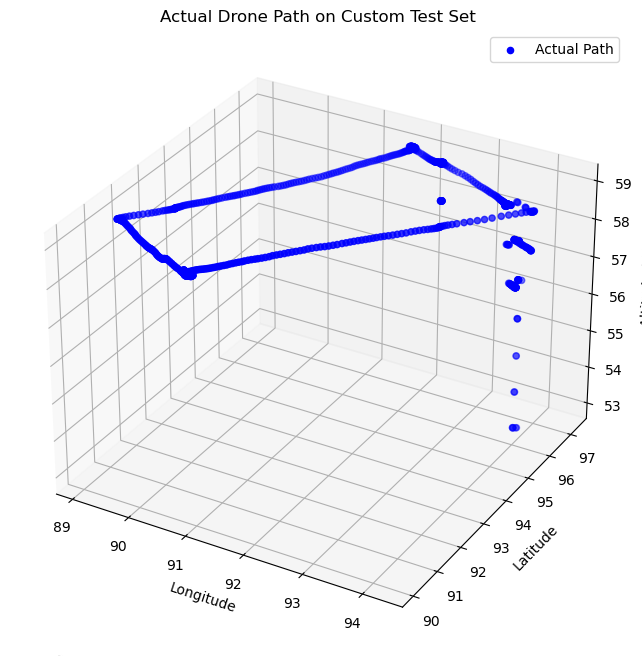

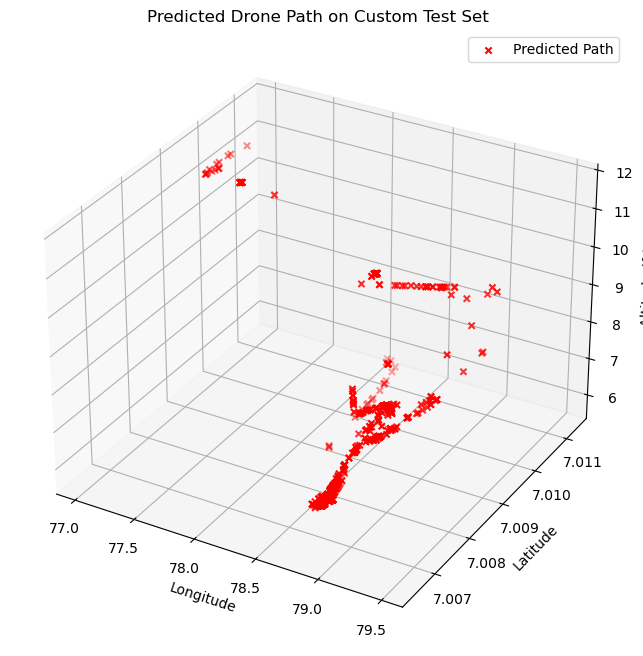

In [2]:
test_folder = 'testing'
test_files = [os.path.join(test_folder, file) for file in os.listdir(test_folder) if file.endswith('.csv')]
df_test_custom = pd.concat([pd.read_csv(file) for file in test_files], ignore_index=True)

# Preprocess 'OSD.flyTime' column in the test dataset
df_test_custom['OSD.flyTime'] = df_test_custom['OSD.flyTime'].apply(time_to_seconds)

# Handling missing values in input features using SimpleImputer
X_test_custom_imputed = imputer.transform(df_test_custom[input_features])

# Normalize the custom test data
X_test_custom_scaled = scaler.transform(X_test_custom_imputed)

# Make predictions on the custom test set
y_pred_custom = model.predict(X_test_custom_scaled)



# Create a 3D plot for the actual drone path on custom test set
fig_actual_custom = plt.figure(figsize=(12, 8))
ax_actual_custom = fig_actual_custom.add_subplot(111, projection='3d')
ax_actual_custom.scatter(df_test_custom['OSD.longitude'], df_test_custom['OSD.latitude'], df_test_custom['OSD.altitude [ft]'], c='blue', marker='o', label='Actual Path')
ax_actual_custom.set_xlabel('Longitude')
ax_actual_custom.set_ylabel('Latitude')
ax_actual_custom.set_zlabel('Altitude (ft)')
ax_actual_custom.set_title('Actual Drone Path on Custom Test Set')
ax_actual_custom.legend()

# Create a 3D plot for the predicted drone path on custom test set
fig_predicted_custom = plt.figure(figsize=(12, 8))
ax_predicted_custom = fig_predicted_custom.add_subplot(111, projection='3d')
ax_predicted_custom.scatter(y_pred_custom[:, 0], y_pred_custom[:, 1], y_pred_custom[:, 2], c='red', marker='x', label='Predicted Path')
ax_predicted_custom.set_xlabel('Longitude')
ax_predicted_custom.set_ylabel('Latitude')
ax_predicted_custom.set_zlabel('Altitude (ft)')
ax_predicted_custom.set_title('Predicted Drone Path on Custom Test Set')
ax_predicted_custom.legend()

# Show the actual and predicted path plots on the custom test set
plt.show()



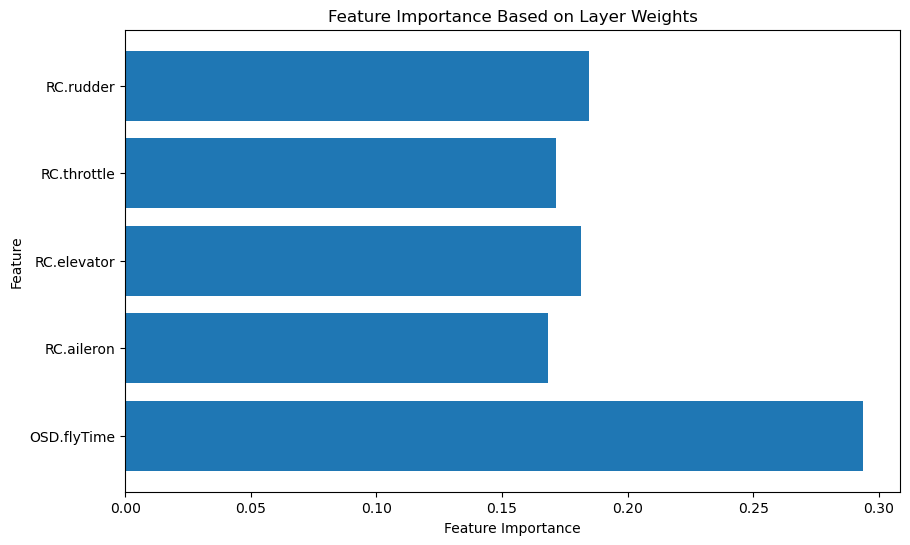

In [3]:
import matplotlib.pyplot as plt

# Get the weights of the first layer
weights = model.layers[0].get_weights()[0]

# Compute feature importance by taking the absolute sum of weights along the feature dimension
feature_importance = np.abs(weights).sum(axis=1)

# Normalize feature importance to sum up to 1
feature_importance /= feature_importance.sum()

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(input_features, feature_importance)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance Based on Layer Weights')
plt.show()


In [5]:
# Define the number of top samples to inspect
k = 10  # You can adjust this value as needed

# Calculate individual errors
individual_errors = y_pred - y_test.values

# Calculate absolute individual errors
absolute_errors = np.abs(individual_errors)

# Find indices of samples with highest absolute errors
top_k_indices = np.argsort(absolute_errors.sum(axis=1))[::-1][:k]

# Display information about the top-k samples with highest errors
for i in top_k_indices:
    print(f"Sample {i}:")
    print("Predicted:", y_pred[i])
    print("Actual:", y_test.values[i])
    print("Individual Errors:", individual_errors[i])
    print("Absolute Errors:", absolute_errors[i])
    print()


Sample 12085:
Predicted: [79.34859     7.010351   15.440754    1.3462646  -0.78835416  9.026445  ]
Actual: [  79.91581822    6.97296832   67.2           3.8          -4.8
 -179.6       ]
Individual Errors: [-5.67231184e-01  3.73828600e-02 -5.17592461e+01 -2.45373540e+00
  4.01164584e+00  1.88626445e+02]
Absolute Errors: [5.67231184e-01 3.73828600e-02 5.17592461e+01 2.45373540e+00
 4.01164584e+00 1.88626445e+02]

Sample 2121:
Predicted: [79.34888     7.0103893  15.5536785   1.3612802  -0.78903836  8.981047  ]
Actual: [  79.91581863    6.97296821   66.9           4.8          -3.5
 -179.3       ]
Individual Errors: [-5.66941677e-01  3.74211190e-02 -5.13463215e+01 -3.43871980e+00
  2.71096164e+00  1.88281047e+02]
Absolute Errors: [5.66941677e-01 3.74211190e-02 5.13463215e+01 3.43871980e+00
 2.71096164e+00 1.88281047e+02]

Sample 13480:
Predicted: [79.3489     7.0103917 15.560736   1.3622186 -0.7890811  8.9782095]
Actual: [  79.91581863    6.97296825   66.9           4.4          -3.8
 -17

In [16]:
# Get the weights of the first layer of the neural network
weights = model.layers[0].get_weights()[0]

# Calculate the absolute sum of weights for each feature
feature_importance = np.abs(weights).sum(axis=0)

# Normalize the feature importances
normalized_importance = feature_importance / feature_importance.sum()

# Create a dictionary mapping feature names to their importances
feature_importance_dict = dict(zip(input_features, normalized_importance))

# Sort the features by importance
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)

# Print the sorted features and their importances
for feature, importance in sorted_features:
    print(f"{feature}: {importance:.4f}")


OSD.flyTime: 0.0405
RC.aileron: 0.0322
RC.elevator: 0.0262
RC.throttle: 0.0191
RC.rudder: 0.0144


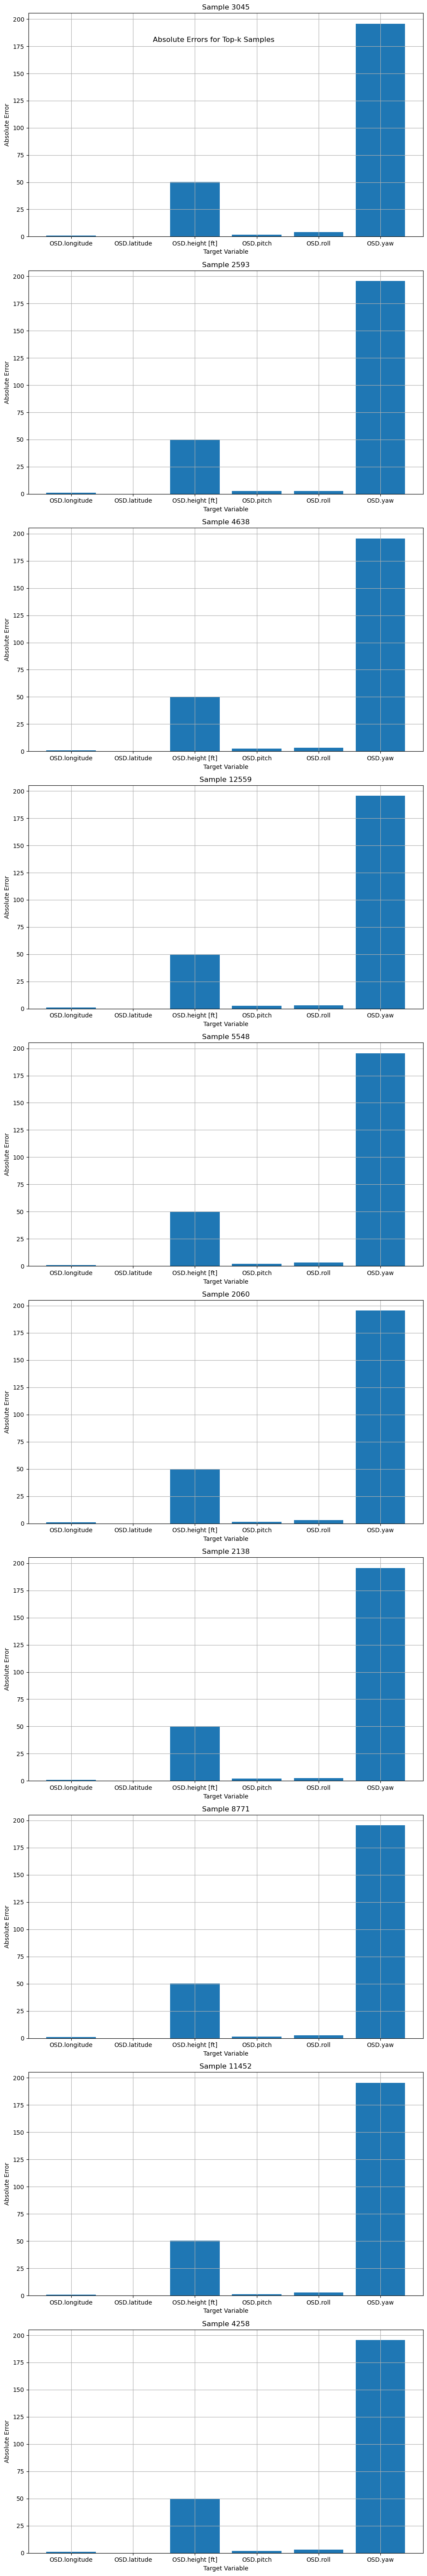

In [17]:
import matplotlib.pyplot as plt

# Define the number of top samples to inspect
k = 10  # You can adjust this value as needed

# Calculate individual errors
individual_errors = y_pred - y_test.values

# Calculate absolute individual errors
absolute_errors = np.abs(individual_errors)

# Find indices of samples with highest absolute errors
top_k_indices = np.argsort(absolute_errors.sum(axis=1))[::-1][:k]

# Plot individual errors for each top-k sample
fig, axes = plt.subplots(k, 1, figsize=(10, 6 * k))
fig.suptitle('Absolute Errors for Top-k Samples')

for i, sample_idx in enumerate(top_k_indices):
    ax = axes[i]
    ax.bar(output_targets, absolute_errors[sample_idx])
    ax.set_title(f"Sample {sample_idx}")
    ax.set_ylabel('Absolute Error')
    ax.set_xlabel('Target Variable')
    ax.grid(True)

plt.tight_layout()
plt.show()


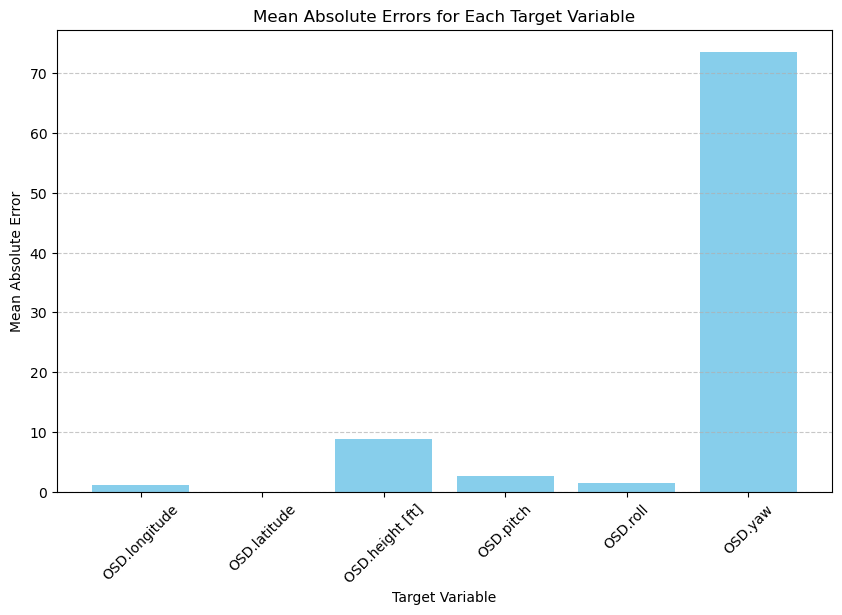

In [11]:
import matplotlib.pyplot as plt

# Calculate mean absolute errors for each target variable
mean_absolute_errors = absolute_errors.mean(axis=0)

# Plot bar graph for mean absolute errors
plt.figure(figsize=(10, 6))
plt.bar(y.columns, mean_absolute_errors, color='skyblue')
plt.title('Mean Absolute Errors for Each Target Variable')
plt.xlabel('Target Variable')
plt.ylabel('Mean Absolute Error')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
